# TP3 — Parte 2
## Salar del Hombre Muerto: exploración y etiquetado asistido con aprendizaje no supervisado

Este notebook trabaja **exclusivamente con el Salar del Hombre Muerto**.

El objetivo es comenzar una metodología rigurosa de construcción de etiquetas a partir de
los productos Sentinel-2 ya generados por el pipeline de descarga y preprocesamiento.

---

## Objetivo de esta etapa

Partimos de:

```text
raster/
└── hombre_muerto/
    ├── hombre_muerto_sentinel2_spectral_median.tif
    ├── hombre_muerto_sentinel2_features_median.tif
    ├── hombre_muerto_qa_valid_count.tif
    └── hombre_muerto_qa_valid_fraction.tif
```

El cubo de `features` contiene:

### Bandas espectrales
- B02, B03, B04
- B05, B06, B07
- B08, B8A
- B11, B12

### Índices
- NDVI
- NDWI
- MNDWI
- NDMI
- BSI

---

## Hipótesis de trabajo

Queremos estudiar si la estructura espectral del salar permite encontrar agrupamientos
coherentes que sirvan de apoyo para construir cuatro macroclases posteriores:

1. `salina`
2. `suelo_desnudo`
3. `agua_humedad`
4. `suelo_rocoso`

**K-Means no conoce esos nombres.**

El procedimiento correcto es:

\[
\text{features}
\rightarrow
\text{clusters}
\rightarrow
\text{interpretación física}
\rightarrow
\text{revisión QGIS}
\rightarrow
\text{polígonos confiables}
\rightarrow
\text{etiquetas supervisadas}
\]

No se utilizará el raster de K-Means directamente como *ground truth*.

# 1. Imports

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window
from rasterio.enums import Resampling
from rasterio.transform import xy as raster_xy

from shapely.geometry import Point
from scipy.ndimage import binary_erosion

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

from joblib import dump

# 2. Versiones del entorno

Conviene conservar esta información junto con los resultados del experimento.

In [2]:
import sklearn
import scipy

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)
print("Rasterio:", rasterio.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

Python: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:36:12) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.1
Pandas: 3.0.5
GeoPandas: 1.1.4
Rasterio: 1.5.1
scikit-learn: 1.9.0
SciPy: 1.18.0


# 3. Configuración

### Sobre `k_final`

El objetivo semántico tiene cuatro macroclases, pero **no es obligatorio usar K=4**.

Es posible que, por ejemplo:

- la salina seca y la salina húmeda formen clusters distintos;
- el suelo rocoso tenga varias firmas;
- agua libre y sedimento húmedo se separen.

Por eso primero probaremos varios valores de \(K\).

Se deja `k_final=6` como punto de partida de **sobre-clustering exploratorio**.
Después de mirar métricas, firmas y mapas puede cambiarse.

In [3]:
@dataclass(frozen=True)
class Config:
    salar_key: str = "hombre_muerto"

    features: tuple[str, ...] = (
        "B04", "B03", "B02",
        "B05", "B06", "B07",
        "B08", "B8A", "B11", "B12",
        "NDVI", "NDWI", "MNDWI", "NDMI", "BSI",
    )

    indices: tuple[str, ...] = (
        "NDVI",
        "NDWI",
        "MNDWI",
        "NDMI",
        "BSI",
    )

    # Umbral exploratorio de calidad temporal.
    qa_min: float = 0.5

    # Muestra usada para ajustar K-Means.
    sample_size: int = 300_000

    random_state: int = 42

    # Se exploran distintos números de clusters.
    k_values: tuple[int, ...] = tuple(range(3, 7))

    # Modelo elegido inicialmente para generar el mapa.
    k_final: int = 4

    minibatch_size: int = 8192
    silhouette_sample_size: int = 20_000

    # Procesamiento del raster completo.
    block_size: int = 512

    # Puntos de núcleo por cluster para inspeccionar en QGIS.
    points_per_cluster: int = 75

    # Erosión de un píxel para evitar bordes, cuando sea posible.
    erosion_iterations: int = 1

    experiment_name: str = "hombre_muerto_kmeans_v1"


CFG = Config()
CFG

Config(salar_key='hombre_muerto', features=('B04', 'B03', 'B02', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDMI', 'BSI'), indices=('NDVI', 'NDWI', 'MNDWI', 'NDMI', 'BSI'), qa_min=0.5, sample_size=300000, random_state=42, k_values=(3, 4, 5, 6), k_final=4, minibatch_size=8192, silhouette_sample_size=20000, block_size=512, points_per_cluster=75, erosion_iterations=1, experiment_name='hombre_muerto_kmeans_v1')

# 4. Detectar la raíz del proyecto

In [4]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "raster").exists():
            return candidate

    raise FileNotFoundError(
        "No se encontró una carpeta 'raster/'. "
        "Ejecute el notebook dentro del proyecto o defina ROOT manualmente."
    )


ROOT = find_project_root()

RASTER_DIR = ROOT / "raster"
METADATA_DIR = ROOT / "metadata"
LABELS_DIR = ROOT / "labels"

EXP_DIR = ROOT / "unsupervised" / CFG.experiment_name
MODEL_DIR = EXP_DIR / "models"
TABLE_DIR = EXP_DIR / "tables"
RASTER_OUT_DIR = EXP_DIR / "rasters"
QGIS_DIR = EXP_DIR / "qgis"

for folder in [
    EXP_DIR,
    MODEL_DIR,
    TABLE_DIR,
    RASTER_OUT_DIR,
    QGIS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("EXP_DIR:", EXP_DIR)

ROOT: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito
EXP_DIR: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\unsupervised\hombre_muerto_kmeans_v1


# 5. Localizar los productos de Hombre Muerto

In [5]:
SALAR = CFG.salar_key

SPECTRAL_PATH = (
    RASTER_DIR
    / SALAR
    / f"{SALAR}_sentinel2_spectral_median.tif"
)

FEATURES_PATH = (
    RASTER_DIR
    / SALAR
    / f"{SALAR}_sentinel2_features_median.tif"
)

QA_COUNT_PATH = (
    RASTER_DIR
    / SALAR
    / f"{SALAR}_qa_valid_count.tif"
)

QA_FRACTION_PATH = (
    RASTER_DIR
    / SALAR
    / f"{SALAR}_qa_valid_fraction.tif"
)

PRODUCTS = {
    "spectral": SPECTRAL_PATH,
    "features": FEATURES_PATH,
    "qa_valid_count": QA_COUNT_PATH,
    "qa_valid_fraction": QA_FRACTION_PATH,
}

for name, path in PRODUCTS.items():
    print(
        f"{name:20s}",
        "OK" if path.exists() else "FALTA",
        path,
    )

spectral             OK C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\raster\hombre_muerto\hombre_muerto_sentinel2_spectral_median.tif
features             OK C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\raster\hombre_muerto\hombre_muerto_sentinel2_features_median.tif
qa_valid_count       OK C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\raster\hombre_muerto\hombre_muerto_qa_valid_count.tif
qa_valid_fraction    OK C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\raster\hombre_muerto\hombre_muerto_qa_valid_fraction.tif


In [6]:
missing = [
    str(path)
    for path in PRODUCTS.values()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Faltan productos necesarios:\n"
        + "\n".join(missing)
    )

print("OK: se encontraron los cuatro productos.")

OK: se encontraron los cuatro productos.


# 6. ¿Qué se descargó realmente?

Esta función muestra:

- CRS;
- extensión raster;
- resolución;
- tamaño;
- número de bandas;
- dtype;
- NoData;
- nombre de cada banda.

In [7]:
def describe_raster(path: Path) -> dict:
    with rasterio.open(path) as src:
        info = {
            "archivo": path.name,
            "crs": str(src.crs),
            "ancho": src.width,
            "alto": src.height,
            "resolucion": src.res,
            "bandas": src.count,
            "dtype": src.dtypes,
            "nodata": src.nodata,
            "descripciones": src.descriptions,
            "bounds": src.bounds,
        }

    return info


for name, path in PRODUCTS.items():
    print("=" * 80)
    print(name.upper())

    info = describe_raster(path)

    for key, value in info.items():
        print(f"{key}: {value}")

SPECTRAL
archivo: hombre_muerto_sentinel2_spectral_median.tif
crs: EPSG:32719
ancho: 2501
alto: 2501
resolucion: (20.0, 20.0)
bandas: 10
dtype: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')
nodata: nan
descripciones: ('B04', 'B03', 'B02', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12')
bounds: BoundingBox(left=666690.0, bottom=7161710.0, right=716710.0, top=7211730.0)
FEATURES
archivo: hombre_muerto_sentinel2_features_median.tif
crs: EPSG:32719
ancho: 2501
alto: 2501
resolucion: (20.0, 20.0)
bandas: 15
dtype: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')
nodata: nan
descripciones: ('B04', 'B03', 'B02', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDMI', 'BSI')
bounds: BoundingBox(left=666690.0, bottom=7161710.0, right=716710.0, top=7211730.0)
QA_VALID_COUNT
archivo: hombre_

# 7. Validar el cubo de 15 features

Para que el análisis sea reproducible, verificamos el nombre y el orden.

In [8]:
with rasterio.open(FEATURES_PATH) as src:
    feature_names = list(src.descriptions)

print("Features encontradas:")
print(feature_names)

if feature_names != list(CFG.features):
    raise ValueError(
        "El orden/nombre de las features no coincide con lo esperado.\n"
        f"Esperado: {list(CFG.features)}\n"
        f"Encontrado: {feature_names}"
    )

print("OK: cubo de features compatible.")

Features encontradas:
['B04', 'B03', 'B02', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDMI', 'BSI']
OK: cubo de features compatible.


# 8. Helpers de visualización

Las imágenes que siguen se leen con reducción de resolución para mostrarlas rápidamente.
**Esto no modifica el raster ni los datos que se usarán en ML.**

In [9]:
def read_band_preview(
    path: Path,
    band_name: str | None = None,
    band_index: int | None = None,
    max_size: int = 1400,
    resampling: Resampling = Resampling.bilinear,
) -> np.ndarray:

    with rasterio.open(path) as src:

        # ---------------------------------------------------------
        # Selección de banda
        # ---------------------------------------------------------
        if band_name is not None:

            names = list(src.descriptions)

            if band_name not in names:
                raise ValueError(
                    f"{band_name!r} no existe en {path.name}. "
                    f"Disponibles: {names}"
                )

            index = names.index(band_name) + 1

        elif band_index is not None:

            index = band_index

        else:
            raise ValueError(
                "Debe indicar band_name o band_index."
            )

        # ---------------------------------------------------------
        # Tamaño del preview
        # ---------------------------------------------------------
        scale = max(
            src.width / max_size,
            src.height / max_size,
            1.0,
        )

        out_width = max(
            1,
            int(src.width / scale),
        )

        out_height = max(
            1,
            int(src.height / scale),
        )

        # ---------------------------------------------------------
        # Lectura
        # ---------------------------------------------------------
        data = src.read(
            index,
            out_shape=(
                out_height,
                out_width,
            ),
            resampling=resampling,
            masked=True,
        )

        # IMPORTANTE:
        # convertir a float ANTES de rellenar la máscara con NaN.
        data = data.astype(
            np.float32
        )

        return data.filled(
            np.nan
        )

In [10]:
def robust_stretch(
    image: np.ndarray,
    p_low: float = 2,
    p_high: float = 98,
) -> np.ndarray:
    out = np.zeros_like(
        image,
        dtype=np.float32,
    )

    for channel in range(image.shape[2]):
        band = image[:, :, channel]
        valid = np.isfinite(band)

        if not valid.any():
            continue

        low, high = np.nanpercentile(
            band[valid],
            [p_low, p_high],
        )

        if high <= low:
            continue

        out[:, :, channel] = np.clip(
            (band - low) / (high - low),
            0,
            1,
        )

    return out

# 9. Composición RGB

\[
R=B04,\quad G=B03,\quad B=B02
\]

Esta es la primera inspección visual obligatoria.

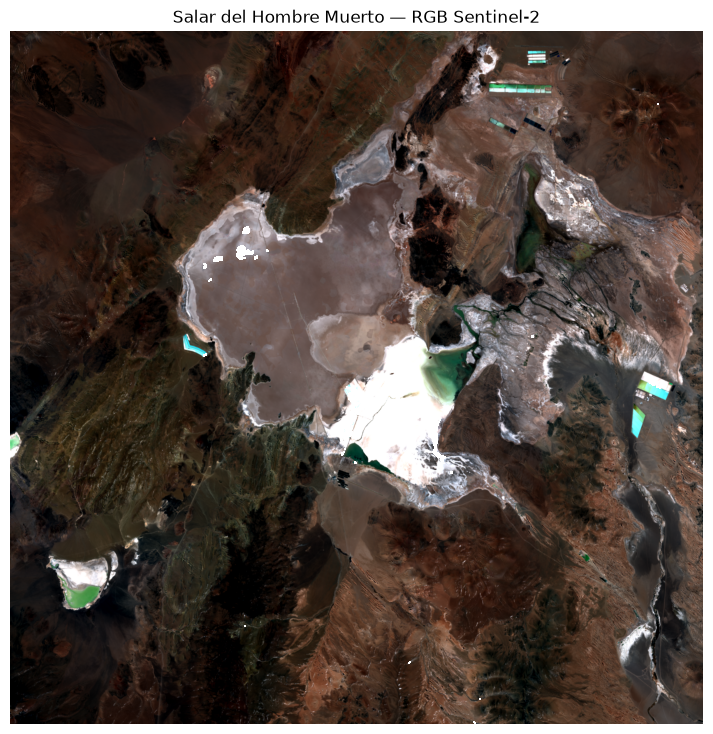

In [11]:
red = read_band_preview(
    SPECTRAL_PATH,
    band_name="B04",
)

green = read_band_preview(
    SPECTRAL_PATH,
    band_name="B03",
)

blue = read_band_preview(
    SPECTRAL_PATH,
    band_name="B02",
)

rgb = robust_stretch(
    np.dstack([red, green, blue])
)

plt.figure(figsize=(11, 9))
plt.imshow(rgb)
plt.title("Salar del Hombre Muerto — RGB Sentinel-2")
plt.axis("off")
plt.show()

# 10. Falso color NIR / Rojo / Verde

\[
R=B08,\quad G=B04,\quad B=B03
\]

Ayuda a resaltar diferencias entre agua, vegetación, suelo y materiales minerales.

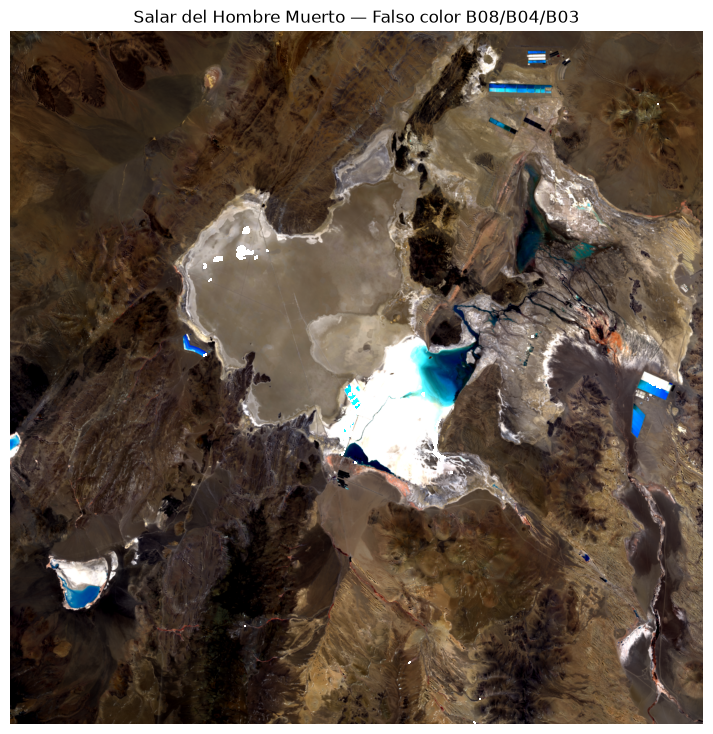

In [12]:
nir = read_band_preview(
    SPECTRAL_PATH,
    band_name="B08",
)

false_color = robust_stretch(
    np.dstack([nir, red, green])
)

plt.figure(figsize=(11, 9))
plt.imshow(false_color)
plt.title(
    "Salar del Hombre Muerto — Falso color B08/B04/B03"
)
plt.axis("off")
plt.show()

# 11. Visualizar los cinco índices

Los índices son **features auxiliares**, no etiquetas.

- NDVI → contraste vegetación.
- NDWI → agua usando Verde/NIR.
- MNDWI → agua usando Verde/SWIR.
- NDMI → humedad usando NIR/SWIR.
- BSI → contraste asociado a suelo desnudo.

No deben utilizarse como reglas rígidas del tipo `MNDWI > x = agua`.

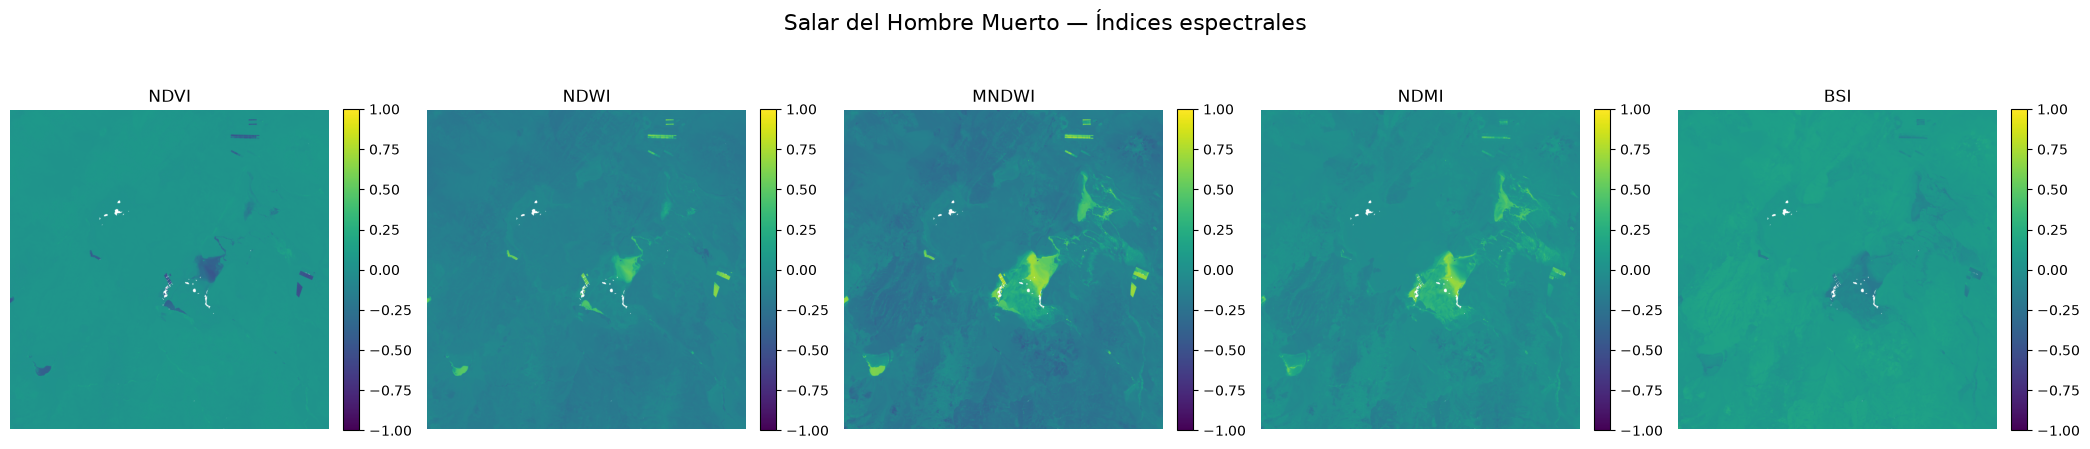

In [13]:
fig, axes = plt.subplots(
    1,
    len(CFG.indices),
    figsize=(21, 5),
)

for ax, index_name in zip(
    axes,
    CFG.indices,
):
    data = read_band_preview(
        FEATURES_PATH,
        band_name=index_name,
    )

    im = ax.imshow(
        data,
        vmin=-1,
        vmax=1,
    )

    ax.set_title(index_name)
    ax.axis("off")

    fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

fig.suptitle(
    "Salar del Hombre Muerto — Índices espectrales",
    fontsize=16,
)

plt.tight_layout()
plt.show()

# 12. Visualizar QA

`qa_valid_fraction` indica la proporción de fechas válidas que contribuyeron al píxel.

El umbral `qa_min` no es una verdad universal: es un criterio de calidad que debe
documentarse y, si corresponde, evaluarse por sensibilidad.

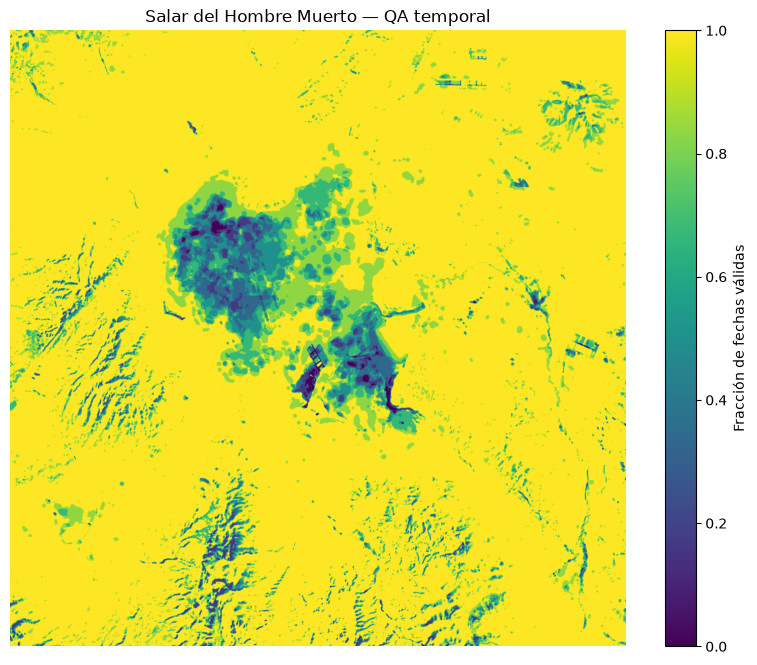

In [14]:
qa_preview = read_band_preview(
    QA_FRACTION_PATH,
    band_index=1,
)

plt.figure(figsize=(10, 8))

im = plt.imshow(
    qa_preview,
    vmin=0,
    vmax=1,
)

plt.colorbar(
    im,
    label="Fracción de fechas válidas",
)

plt.title(
    "Salar del Hombre Muerto — QA temporal"
)

plt.axis("off")
plt.show()

# 13. Muestreo reproducible del salar

El raster completo puede contener millones de píxeles.

Para ajustar K-Means tomaremos una muestra aleatoria de píxeles que cumplan:

1. las 15 features son finitas;
2. `qa_valid_fraction >= qa_min`.

La lectura se hace por ventanas para evitar cargar el cubo completo en RAM.

In [15]:
def sample_hombre_muerto(
    features_path: Path,
    qa_path: Path,
    sample_size: int,
    qa_min: float,
    random_state: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(
        random_state
    )

    reservoir_X = None
    reservoir_keys = None

    with (
        rasterio.open(features_path) as src,
        rasterio.open(qa_path) as qa_src,
    ):
        if (
            src.width != qa_src.width
            or src.height != qa_src.height
            or src.transform != qa_src.transform
        ):
            raise ValueError(
                "El raster de features y QA no comparte la misma grilla."
            )

        names = list(src.descriptions)

        for _, window in src.block_windows(1):
            cube = src.read(
                window=window,
                masked=True,
            ).filled(np.nan).astype(np.float32)

            qa = qa_src.read(
                1,
                window=window,
                masked=True,
            ).filled(np.nan).astype(np.float32)

            X_block = cube.reshape(
                cube.shape[0],
                -1,
            ).T

            qa_flat = qa.ravel()

            valid = (
                np.all(
                    np.isfinite(X_block),
                    axis=1,
                )
                & np.isfinite(qa_flat)
                & (qa_flat >= qa_min)
            )

            X_valid = X_block[valid]

            if len(X_valid) == 0:
                continue

            keys = rng.random(
                len(X_valid)
            )

            if reservoir_X is None:
                combined_X = X_valid
                combined_keys = keys
            else:
                combined_X = np.vstack(
                    [reservoir_X, X_valid]
                )

                combined_keys = np.concatenate(
                    [reservoir_keys, keys]
                )

            if len(combined_X) > sample_size:
                keep = np.argpartition(
                    combined_keys,
                    sample_size - 1,
                )[:sample_size]

                reservoir_X = combined_X[keep]
                reservoir_keys = combined_keys[keep]
            else:
                reservoir_X = combined_X
                reservoir_keys = combined_keys

    if reservoir_X is None:
        raise RuntimeError(
            "No se encontraron píxeles válidos."
        )

    df = pd.DataFrame(
        reservoir_X,
        columns=names,
    )

    return df.reset_index(drop=True)

In [16]:
sample_df = sample_hombre_muerto(
    features_path=FEATURES_PATH,
    qa_path=QA_FRACTION_PATH,
    sample_size=CFG.sample_size,
    qa_min=CFG.qa_min,
    random_state=CFG.random_state,
)

print("Muestra:", sample_df.shape)
sample_df.head()

Muestra: (300000, 15)


,B04,B03,B02,B05,B06,B07,B08,B8A,B11,B12,NDVI,NDWI,MNDWI,NDMI,BSI
0,3425.25,2695.75,2191.00,3564.75,3648.75,3726.0,3804.00,3798.25,4143.00,3945.75,0.052391,-0.170507,-0.211625,-0.042658,0.115994
1,2809.50,2156.25,1800.75,2959.75,3021.75,3069.0,3061.75,3044.00,3295.00,3254.25,0.042964,-0.173534,-0.208897,-0.036693,0.113249
2,2795.25,2131.50,1780.50,2928.75,3025.25,3085.5,3096.50,3077.75,3470.25,3398.25,0.051131,-0.184583,-0.238988,-0.056916,0.124613
3,2818.00,2176.50,1803.50,2966.00,3042.25,3066.0,3075.25,3061.00,3171.50,3111.25,0.043652,-0.171133,-0.186051,-0.015408,0.102201
4,2902.00,2211.25,1838.50,3026.75,3094.25,3128.0,3215.00,3177.75,3447.00,3369.25,0.051169,-0.184980,-0.218398,-0.034824,0.113615


# 14. Exploración estadística inicial

In [17]:
summary = sample_df.describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).T

summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
B04,300000.0,3275.726562,837.659912,1168.500000,2076.000000,2362.000000,2773.000000,3063.250000,3632.562500,4656.500000,6855.000000,9927.500000
B03,300000.0,2714.884766,797.573303,1168.000000,1791.000000,1968.500000,2239.500000,2486.000000,2966.750000,4080.500000,6314.010000,9536.000000
B02,300000.0,2328.841797,768.046509,1091.500000,1584.247500,1698.000000,1882.000000,2076.000000,2523.250000,3662.500000,5856.505000,9293.000000
B05,300000.0,3400.483887,862.785095,1217.000000,2114.000000,2432.737500,2882.000000,3193.500000,3779.000000,4819.000000,7066.010000,10094.000000
B06,300000.0,3461.145996,868.403870,1028.000000,1941.747500,2451.000000,2953.000000,3279.500000,3857.000000,4866.512500,7047.002500,10029.000000
B07,300000.0,3505.741943,874.951721,1048.000000,1914.495000,2469.500000,2994.500000,3329.000000,3912.500000,4917.500000,7073.010000,10002.000000
B08,300000.0,3513.035889,882.717224,1048.000000,1874.000000,2458.000000,2998.000000,3337.000000,3929.000000,4932.512500,7088.000000,10048.000000
B8A,300000.0,3491.021973,885.864258,1003.000000,1739.995000,2430.500000,2974.500000,3317.500000,3917.500000,4917.750000,7027.010000,9998.000000
B11,300000.0,3660.572998,777.691956,1012.500000,1079.500000,2403.000000,3222.250000,3678.500000,4162.000000,4855.000000,5467.000000,8857.000000
B12,300000.0,3420.703125,747.545959,1004.000000,1071.497500,2199.750000,3001.500000,3412.000000,3903.750000,4572.750000,5128.505000,7466.000000


In [18]:
summary.to_csv(
    TABLE_DIR / "feature_summary.csv"
)

# 15. Correlación entre features

Los índices derivan de las bandas, por lo que es normal observar redundancia.

La matriz sirve para estudiar relaciones, no para eliminar variables automáticamente.

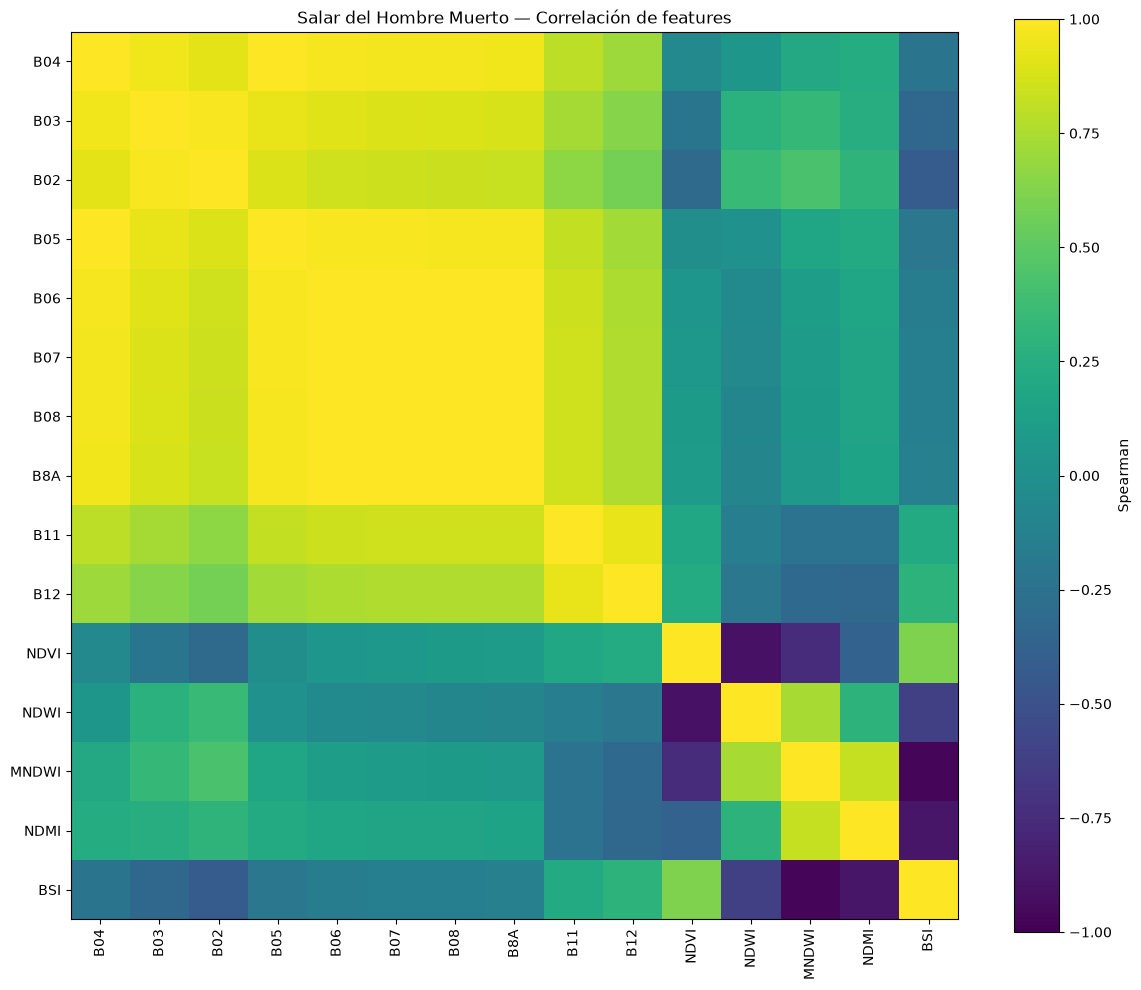

In [19]:
correlation = sample_df.corr(
    method="spearman"
)

plt.figure(figsize=(12, 10))

plt.imshow(
    correlation,
    vmin=-1,
    vmax=1,
)

plt.colorbar(label="Spearman")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90,
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns,
)

plt.title(
    "Salar del Hombre Muerto — Correlación de features"
)

plt.tight_layout()
plt.show()

# 16. Estandarización

K-Means depende de distancias euclídeas, por lo que debemos estandarizar:

\[
z_j = rac{x_j-\mu_j}{\sigma_j}
\]

El escalador debe guardarse y reutilizarse al proyectar el modelo sobre el raster completo.

In [20]:
X = sample_df[
    list(CFG.features)
].to_numpy(
    dtype=np.float32
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print("X:", X.shape)
print("X_scaled:", X_scaled.shape)

X: (300000, 15)
X_scaled: (300000, 15)


# 17. Evaluación de distintos valores de K

Se evalúan:

- Inertia
- Silhouette
- Calinski-Harabasz
- Davies-Bouldin

No existe una única métrica que diga cuál es el “K verdadero”.
La elección debe combinar métricas y sentido geográfico.

In [21]:
def evaluate_k(
    X_scaled: np.ndarray,
    cfg: Config,
):
    rows = []
    models = {}

    silhouette_n = min(
        cfg.silhouette_sample_size,
        len(X_scaled),
    )

    for k in cfg.k_values:
        print("Evaluando K =", k)

        model = MiniBatchKMeans(
            n_clusters=k,
            batch_size=cfg.minibatch_size,
            random_state=cfg.random_state,
            n_init="auto",
        )

        labels = model.fit_predict(
            X_scaled
        )

        rows.append({
            "k": k,
            "inertia": float(model.inertia_),
            "silhouette": float(
                silhouette_score(
                    X_scaled,
                    labels,
                    sample_size=silhouette_n,
                    random_state=cfg.random_state,
                )
            ),
            "calinski_harabasz": float(
                calinski_harabasz_score(
                    X_scaled,
                    labels,
                )
            ),
            "davies_bouldin": float(
                davies_bouldin_score(
                    X_scaled,
                    labels,
                )
            ),
        })

        models[k] = model

    return (
        pd.DataFrame(rows),
        models,
    )


k_metrics_df, candidate_models = (
    evaluate_k(
        X_scaled,
        CFG,
    )
)

k_metrics_df

Evaluando K = 3


C:\Users\pablonicolasr\anaconda3\envs\mento_pdis\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Evaluando K = 4
Evaluando K = 5
Evaluando K = 6


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,3,2.242637e+06,0.510235,152117.125937,0.794645
1,4,1.496590e+06,0.449752,201018.257080,0.724255
2,5,1.288814e+06,0.376418,187527.080395,0.798872
3,6,1.016004e+06,0.329925,206306.976229,0.872117


In [22]:
k_metrics_df.to_csv(
    TABLE_DIR / "k_selection_metrics.csv",
    index=False,
)

# 18. Graficar métricas de K

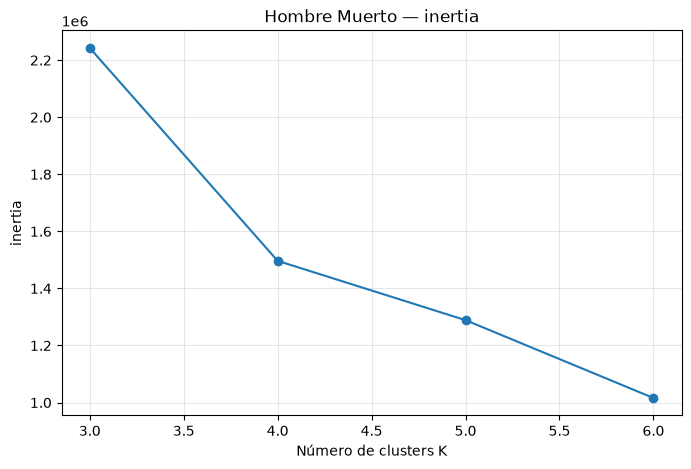

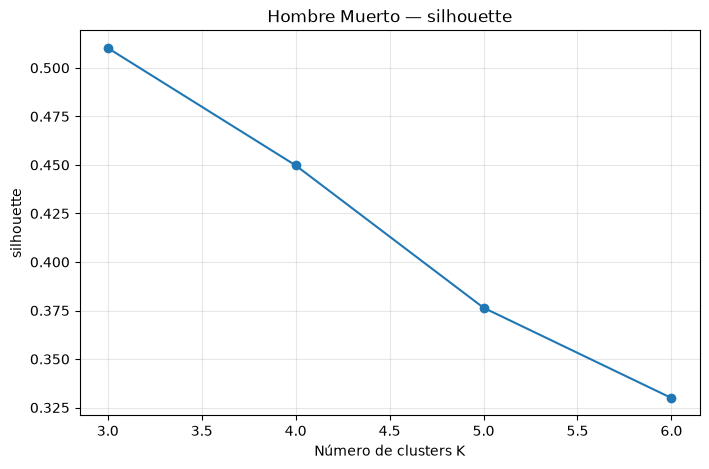

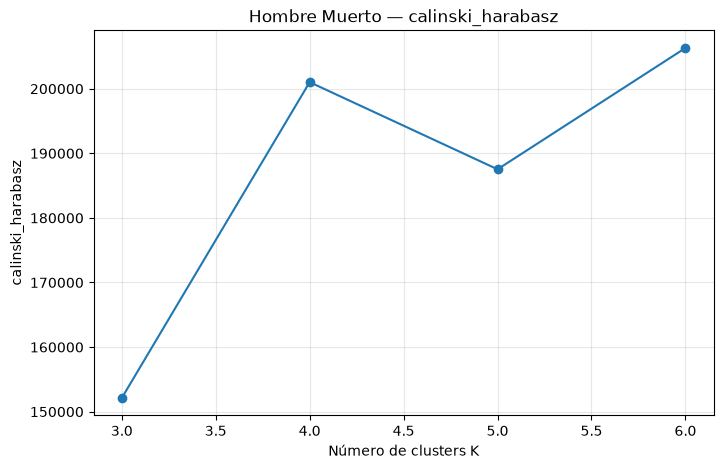

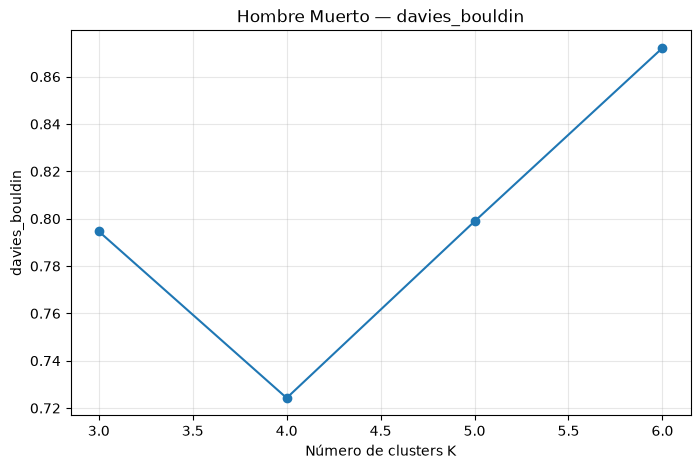

In [23]:
for metric in [
    "inertia",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
]:
    plt.figure(figsize=(8, 5))

    plt.plot(
        k_metrics_df["k"],
        k_metrics_df[metric],
        marker="o",
    )

    plt.xlabel("Número de clusters K")
    plt.ylabel(metric)
    plt.title(
        f"Hombre Muerto — {metric}"
    )

    plt.grid(alpha=0.3)
    plt.show()

# 19. Ajustar / seleccionar el modelo final exploratorio

Después de revisar la celda anterior se puede cambiar:

```python
CFG.k_final
```

y reejecutar desde aquí.

Se usa numeración 1..K para los mapas finales; 0 queda reservado para NoData/no confiable.

In [24]:
if CFG.k_final in candidate_models:
    kmeans = candidate_models[
        CFG.k_final
    ]
else:
    kmeans = MiniBatchKMeans(
        n_clusters=CFG.k_final,
        batch_size=CFG.minibatch_size,
        random_state=CFG.random_state,
        n_init="auto",
    )

    kmeans.fit(X_scaled)

sample_df["cluster"] = (
    kmeans.predict(X_scaled) + 1
).astype(np.int16)

sample_df["cluster"].value_counts().sort_index()

cluster
1    200646
2     88177
3      4621
4      6556
Name: count, dtype: int64

# 20. Guardar scaler y modelo K-Means

In [25]:
SCALER_PATH = (
    MODEL_DIR
    / "standard_scaler.joblib"
)

KMEANS_PATH = (
    MODEL_DIR
    / f"minibatch_kmeans_k{CFG.k_final}.joblib"
)

dump(
    scaler,
    SCALER_PATH,
)

dump(
    kmeans,
    KMEANS_PATH,
)

print(SCALER_PATH)
print(KMEANS_PATH)

C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\unsupervised\hombre_muerto_kmeans_v1\models\standard_scaler.joblib
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\unsupervised\hombre_muerto_kmeans_v1\models\minibatch_kmeans_k4.joblib


# 21. Perfil de cada cluster

Primero observamos las medianas de las 15 variables.

In [26]:
cluster_profile = (
    sample_df
    .groupby("cluster")[
        list(CFG.features)
    ]
    .median()
)

cluster_profile

,B04,B03,B02,B05,B06,B07,B08,B8A,B11,B12,NDVI,NDWI,MNDWI,NDMI,BSI
cluster,,,,,,,,,,,,,,,
1,2878.25,2318.0,1936.5,2999.50,3085.500,3131.625,3138.5,3115.50,3432.0,3231.50,0.040231,-0.140711,-0.181977,-0.034621,0.100163
2,3855.00,3178.0,2760.5,4012.00,4093.000,4153.000,4163.0,4155.25,4337.5,4179.75,0.035817,-0.129773,-0.149201,-0.019960,0.082201
3,3164.00,3198.0,2522.5,2951.00,1993.500,1896.000,1811.0,1522.00,1060.0,1055.50,-0.299695,0.309813,0.492763,0.230244,-0.027015
4,6694.50,6046.5,5601.0,6905.25,6886.875,6917.000,6931.5,6878.50,4581.0,3110.75,0.017479,-0.065400,0.164443,0.232177,-0.065563


In [27]:
cluster_profile.to_csv(
    TABLE_DIR
    / "cluster_feature_median.csv"
)

# 22. Firma espectral de cada cluster

Se muestran sólo las bandas originales.

La forma de la firma es más útil que mirar un cluster como un simple número.

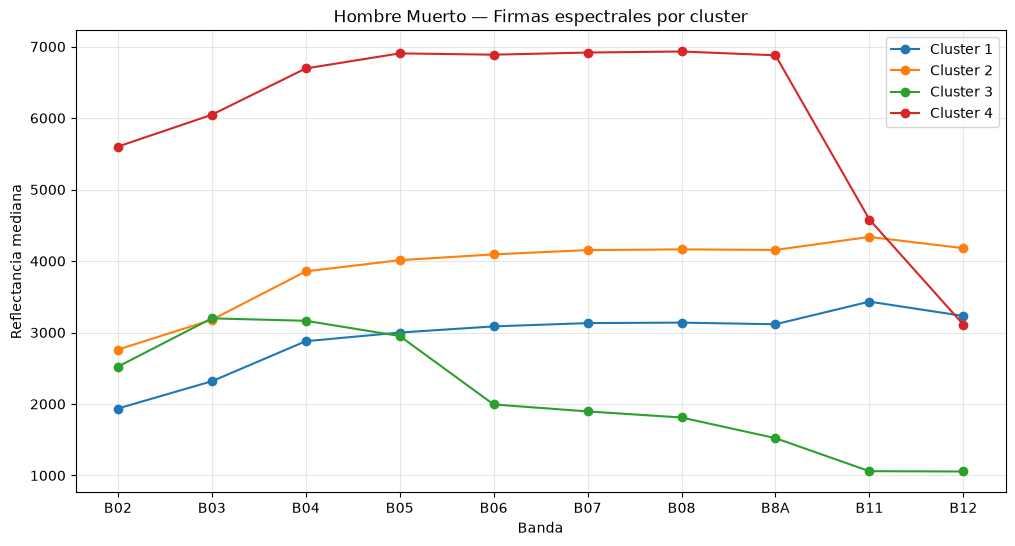

In [28]:
SPECTRAL_BANDS = [
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B11",
    "B12",
]

spectral_profile = (
    sample_df
    .groupby("cluster")[
        SPECTRAL_BANDS
    ]
    .median()
)

plt.figure(figsize=(12, 6))

for cluster_id, row in spectral_profile.iterrows():
    plt.plot(
        SPECTRAL_BANDS,
        row.values,
        marker="o",
        label=f"Cluster {cluster_id}",
    )

plt.xlabel("Banda")
plt.ylabel("Reflectancia mediana")
plt.title(
    "Hombre Muerto — Firmas espectrales por cluster"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 23. Perfil de índices por cluster

In [29]:
index_profile = (
    sample_df
    .groupby("cluster")[
        list(CFG.indices)
    ]
    .median()
)

index_profile

,NDVI,NDWI,MNDWI,NDMI,BSI
cluster,,,,,
1,0.040231,-0.140711,-0.181977,-0.034621,0.100163
2,0.035817,-0.129773,-0.149201,-0.019960,0.082201
3,-0.299695,0.309813,0.492763,0.230244,-0.027015
4,0.017479,-0.065400,0.164443,0.232177,-0.065563


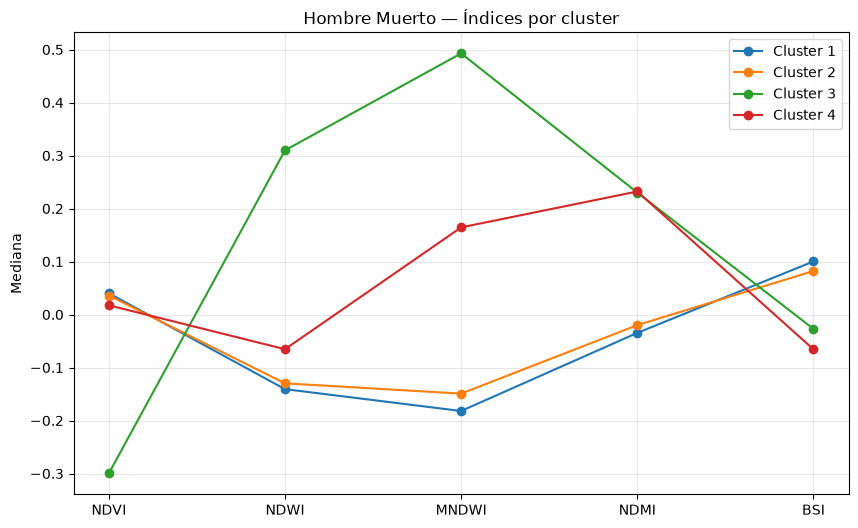

In [30]:
plt.figure(figsize=(10, 6))

for cluster_id, row in index_profile.iterrows():
    plt.plot(
        list(CFG.indices),
        row.values,
        marker="o",
        label=f"Cluster {cluster_id}",
    )

plt.ylabel("Mediana")
plt.title(
    "Hombre Muerto — Índices por cluster"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 24. PCA para visualizar los clusters

PCA se utiliza aquí para visualización.

El clustering anterior continúa usando las 15 features estandarizadas.

In [31]:
pca = PCA(
    n_components=2,
    random_state=CFG.random_state,
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "Varianza explicada PC1:",
    pca.explained_variance_ratio_[0],
)

print(
    "Varianza explicada PC2:",
    pca.explained_variance_ratio_[1],
)

print(
    "Total PC1+PC2:",
    pca.explained_variance_ratio_.sum(),
)

Varianza explicada PC1: 0.5913565
Varianza explicada PC2: 0.31137615
Total PC1+PC2: 0.9027327


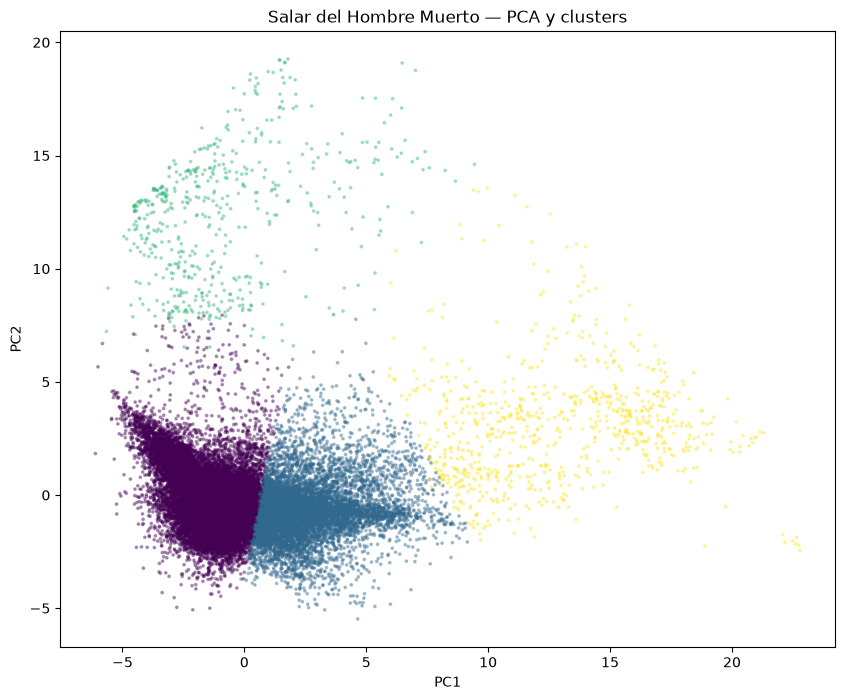

In [32]:
rng = np.random.default_rng(
    CFG.random_state
)

n_plot = min(
    35_000,
    len(X_pca),
)

plot_idx = rng.choice(
    len(X_pca),
    size=n_plot,
    replace=False,
)

plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[plot_idx, 0],
    X_pca[plot_idx, 1],
    c=sample_df["cluster"].to_numpy()[plot_idx],
    s=3,
    alpha=0.35,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "Salar del Hombre Muerto — PCA y clusters"
)

plt.show()

# 25. Proyectar K-Means sobre todo Hombre Muerto

Ahora sí clasificamos cada píxel válido del raster completo.

Se generan dos productos:

### 1. Raster de clusters

```text
hombre_muerto_kmeans_kN.tif
```

Valores:

```text
0 = NoData / QA insuficiente
1..K = cluster
```

### 2. Distancia al centroide

```text
hombre_muerto_kmeans_kN_distance.tif
```

Una distancia baja indica que el píxel es espectralmente representativo de su cluster.

**No es una probabilidad.**

In [33]:
CLUSTER_RASTER = (
    RASTER_OUT_DIR
    / f"hombre_muerto_kmeans_k{CFG.k_final}.tif"
)

DISTANCE_RASTER = (
    RASTER_OUT_DIR
    / f"hombre_muerto_kmeans_k{CFG.k_final}_distance.tif"
)


def project_kmeans_to_raster(
    features_path: Path,
    qa_path: Path,
    cluster_output: Path,
    distance_output: Path,
    scaler: StandardScaler,
    model: MiniBatchKMeans,
    cfg: Config,
):
    with (
        rasterio.open(features_path) as src,
        rasterio.open(qa_path) as qa_src,
    ):
        if list(src.descriptions) != list(cfg.features):
            raise ValueError(
                "Orden de features inesperado."
            )

        if (
            src.width != qa_src.width
            or src.height != qa_src.height
            or src.transform != qa_src.transform
        ):
            raise ValueError(
                "Features y QA no comparten la misma grilla."
            )

        cluster_profile = src.profile.copy()

        cluster_profile.update(
            count=1,
            dtype="uint8",
            nodata=0,
            compress="DEFLATE",
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        distance_profile = src.profile.copy()

        distance_profile.update(
            count=1,
            dtype="float32",
            nodata=np.nan,
            compress="DEFLATE",
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        with (
            rasterio.open(
                cluster_output,
                "w",
                **cluster_profile,
            ) as cluster_dst,
            rasterio.open(
                distance_output,
                "w",
                **distance_profile,
            ) as distance_dst,
        ):
            for row_off in range(
                0,
                src.height,
                cfg.block_size,
            ):
                height = min(
                    cfg.block_size,
                    src.height - row_off,
                )

                for col_off in range(
                    0,
                    src.width,
                    cfg.block_size,
                ):
                    width = min(
                        cfg.block_size,
                        src.width - col_off,
                    )

                    window = Window(
                        col_off,
                        row_off,
                        width,
                        height,
                    )

                    cube = src.read(
                        window=window,
                        masked=True,
                    ).filled(np.nan).astype(np.float32)

                    qa = qa_src.read(
                        1,
                        window=window,
                        masked=True,
                    ).filled(np.nan).astype(np.float32)

                    X_block = cube.reshape(
                        cube.shape[0],
                        -1,
                    ).T

                    qa_flat = qa.ravel()

                    valid = (
                        np.all(
                            np.isfinite(X_block),
                            axis=1,
                        )
                        & np.isfinite(qa_flat)
                        & (qa_flat >= cfg.qa_min)
                    )

                    clusters = np.zeros(
                        len(X_block),
                        dtype=np.uint8,
                    )

                    distances = np.full(
                        len(X_block),
                        np.nan,
                        dtype=np.float32,
                    )

                    if np.any(valid):
                        X_valid_scaled = scaler.transform(
                            X_block[valid]
                        )

                        labels_zero = model.predict(
                            X_valid_scaled
                        )

                        clusters[valid] = (
                            labels_zero + 1
                        ).astype(np.uint8)

                        centers = (
                            model.cluster_centers_[
                                labels_zero
                            ]
                        )

                        distances[valid] = np.linalg.norm(
                            X_valid_scaled - centers,
                            axis=1,
                        ).astype(np.float32)

                    cluster_dst.write(
                        clusters.reshape(
                            height,
                            width,
                        ),
                        1,
                        window=window,
                    )

                    distance_dst.write(
                        distances.reshape(
                            height,
                            width,
                        ),
                        1,
                        window=window,
                    )

                progress = (
                    100
                    * (row_off + height)
                    / src.height
                )

                print(
                    f"\rProgreso: {progress:6.2f}%",
                    end="",
                )

            print()

            cluster_dst.set_band_description(
                1,
                "KMeans_cluster",
            )

            distance_dst.set_band_description(
                1,
                "distance_to_assigned_centroid",
            )


project_kmeans_to_raster(
    features_path=FEATURES_PATH,
    qa_path=QA_FRACTION_PATH,
    cluster_output=CLUSTER_RASTER,
    distance_output=DISTANCE_RASTER,
    scaler=scaler,
    model=kmeans,
    cfg=CFG,
)

print(CLUSTER_RASTER)
print(DISTANCE_RASTER)

Progreso: 100.00%
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\unsupervised\hombre_muerto_kmeans_v1\rasters\hombre_muerto_kmeans_k4.tif
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\unsupervised\hombre_muerto_kmeans_v1\rasters\hombre_muerto_kmeans_k4_distance.tif


# 26. Mostrar el mapa de clusters

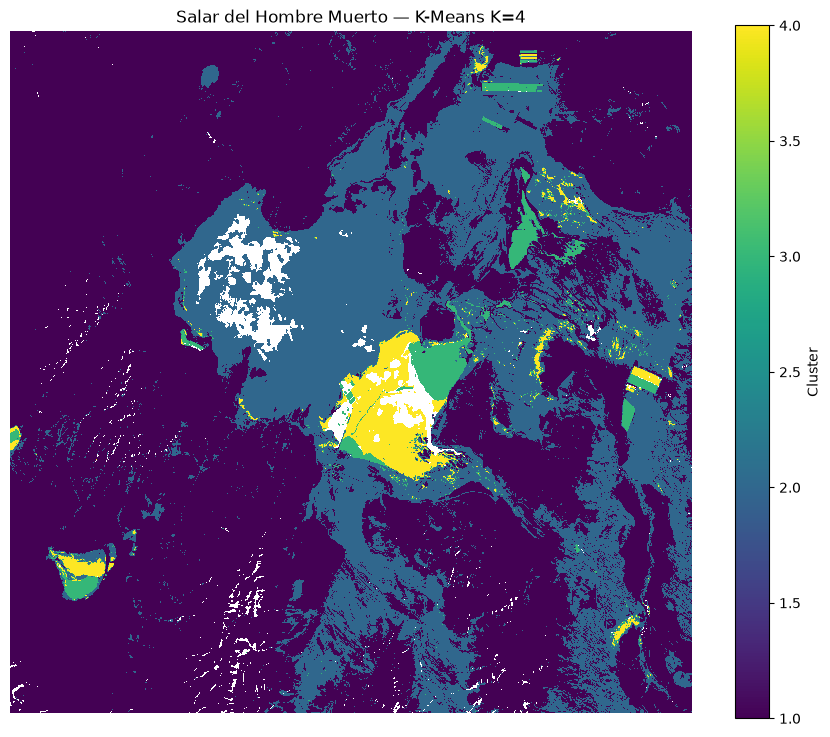

In [34]:
cluster_preview = read_band_preview(
    CLUSTER_RASTER,
    band_index=1,
)

cluster_preview = np.ma.masked_where(
    cluster_preview == 0,
    cluster_preview,
)

plt.figure(figsize=(11, 9))

im = plt.imshow(
    cluster_preview,
    interpolation="nearest",
)

plt.colorbar(
    im,
    label="Cluster",
)

plt.title(
    f"Salar del Hombre Muerto — K-Means K={CFG.k_final}"
)

plt.axis("off")
plt.show()

# 27. Mostrar distancia al centroide

Las regiones más oscuras/cercanas a cero son mejores candidatas para buscar
*píxeles núcleo* de cada cluster.

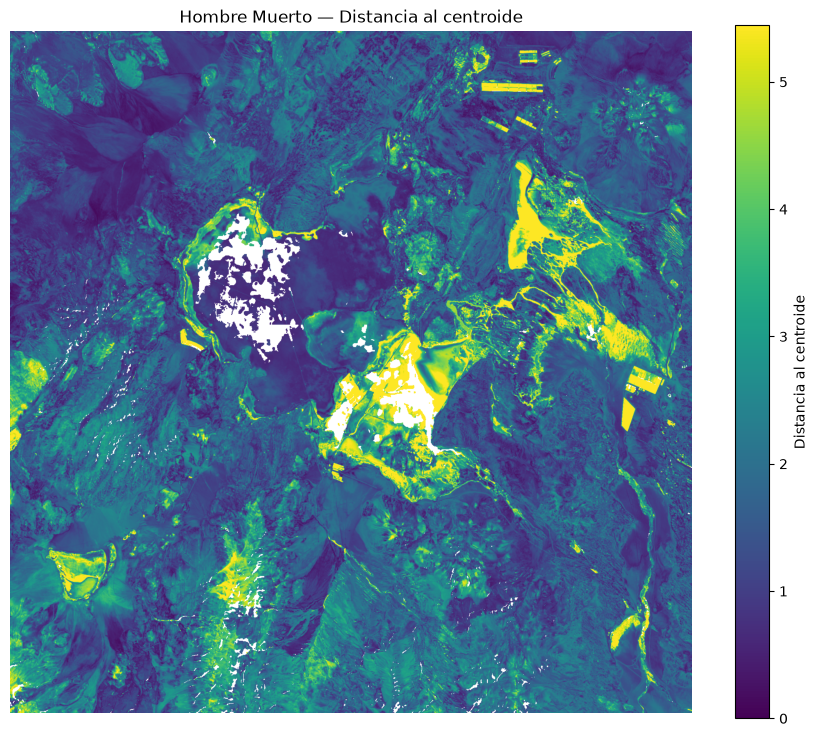

In [35]:
distance_preview = read_band_preview(
    DISTANCE_RASTER,
    band_index=1,
)

finite = distance_preview[
    np.isfinite(distance_preview)
]

vmax = (
    np.nanpercentile(
        finite,
        98,
    )
    if len(finite)
    else 1
)

plt.figure(figsize=(11, 9))

im = plt.imshow(
    distance_preview,
    vmin=0,
    vmax=vmax,
)

plt.colorbar(
    im,
    label="Distancia al centroide",
)

plt.title(
    "Hombre Muerto — Distancia al centroide"
)

plt.axis("off")
plt.show()

# 28. Seleccionar puntos núcleo de cada cluster

La estrategia es:

1. tomar el cluster;
2. erosionar un píxel para evitar bordes;
3. dentro del núcleo buscar los píxeles con menor distancia al centroide;
4. exportarlos como puntos para QGIS.

Son **candidatos de inspección**, no etiquetas finales.

In [36]:
def build_core_points(
    cluster_path: Path,
    distance_path: Path,
    cfg: Config,
) -> gpd.GeoDataFrame:
    with (
        rasterio.open(cluster_path) as csrc,
        rasterio.open(distance_path) as dsrc,
    ):
        clusters = csrc.read(1)

        distances = dsrc.read(
            1,
            masked=True,
        ).filled(np.nan).astype(np.float32)

        transform = csrc.transform
        crs = csrc.crs

    records = []

    for cluster_id in range(
        1,
        cfg.k_final + 1,
    ):
        mask = (
            (clusters == cluster_id)
            & np.isfinite(distances)
        )

        if cfg.erosion_iterations > 0:
            core = binary_erosion(
                mask,
                iterations=cfg.erosion_iterations,
            )

            if (
                core.sum()
                < cfg.points_per_cluster
            ):
                core = mask
        else:
            core = mask

        flat_candidates = np.flatnonzero(
            core.ravel()
        )

        if len(flat_candidates) == 0:
            warnings.warn(
                f"Cluster {cluster_id} sin candidatos."
            )
            continue

        candidate_distances = (
            distances.ravel()[
                flat_candidates
            ]
        )

        n = min(
            cfg.points_per_cluster,
            len(flat_candidates),
        )

        if len(flat_candidates) > n:
            local_ids = np.argpartition(
                candidate_distances,
                n - 1,
            )[:n]

            selected = flat_candidates[
                local_ids
            ]
        else:
            selected = flat_candidates

        rows, cols = np.unravel_index(
            selected,
            clusters.shape,
        )

        for row, col in zip(rows, cols):
            x, y = raster_xy(
                transform,
                row,
                col,
                offset="center",
            )

            records.append({
                "salar": "hombre_muerto",
                "cluster": int(cluster_id),
                "distance": float(
                    distances[row, col]
                ),
                "row": int(row),
                "col": int(col),
                "geometry": Point(x, y),
            })

    return gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs=crs,
    )


core_points = build_core_points(
    CLUSTER_RASTER,
    DISTANCE_RASTER,
    CFG,
)

core_points.head()

,salar,cluster,distance,row,col,geometry
0,hombre_muerto,1,0.057629,1877,1173,POINT (690160 7174180)
1,hombre_muerto,1,0.071989,1724,1081,POINT (688320 7177240)
2,hombre_muerto,1,0.084110,1174,709,POINT (680880 7188240)
3,hombre_muerto,1,0.091889,1312,764,POINT (681980 7185480)
4,hombre_muerto,1,0.092545,656,309,POINT (672880 7198600)


In [37]:
core_points.groupby(
    "cluster"
).size()

cluster
1    75
2    75
3    75
4    75
dtype: int64

# 29. Exportar puntos núcleo para QGIS

In [38]:
CORE_POINTS_GPKG = (
    QGIS_DIR
    / "hombre_muerto_cluster_core_points.gpkg"
)

CORE_POINTS_GEOJSON = (
    QGIS_DIR
    / "hombre_muerto_cluster_core_points.geojson"
)

try:
    core_points.to_file(
        CORE_POINTS_GPKG,
        layer="cluster_core_points",
        driver="GPKG",
    )

    print(
        "GeoPackage:",
        CORE_POINTS_GPKG,
    )

except Exception as exc:
    warnings.warn(
        f"No se pudo crear GPKG: {exc}. "
        "Se guardará GeoJSON."
    )

    core_points.to_file(
        CORE_POINTS_GEOJSON,
        driver="GeoJSON",
    )

    print(
        "GeoJSON:",
        CORE_POINTS_GEOJSON,
    )

GeoPackage: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\g03\nuevito\unsupervised\hombre_muerto_kmeans_v1\qgis\hombre_muerto_cluster_core_points.gpkg


# 30. Plantilla de interpretación de clusters

**No se completa automáticamente.**

Hay que abrir los puntos y los rasters en QGIS y estudiar cada cluster.

Una posibilidad es que dos o más clusters terminen perteneciendo a la misma macroclase.

In [39]:
mapping_template = pd.DataFrame({
    "cluster": range(
        1,
        CFG.k_final + 1,
    ),
    "class_id": [
        pd.NA
        for _ in range(CFG.k_final)
    ],
    "proposed_class": [
        ""
        for _ in range(CFG.k_final)
    ],
    "confidence": [
        pd.NA
        for _ in range(CFG.k_final)
    ],
    "evidence": [
        ""
        for _ in range(CFG.k_final)
    ],
    "notes": [
        ""
        for _ in range(CFG.k_final)
    ],
})

MAPPING_PATH = (
    TABLE_DIR
    / f"cluster_semantic_mapping_k{CFG.k_final}.csv"
)

mapping_template.to_csv(
    MAPPING_PATH,
    index=False,
)

mapping_template

,cluster,class_id,proposed_class,confidence,evidence,notes
0,1,<NA>,,<NA>,,
1,2,<NA>,,<NA>,,
2,3,<NA>,,<NA>,,
3,4,<NA>,,<NA>,,


# 31. Cómo interpretar cada cluster en QGIS

Para cada cluster revisar:

### 1. RGB
¿Dónde aparece espacialmente?

### 2. B11 / B12
¿Tiene una respuesta SWIR característica?

### 3. NDWI y MNDWI
¿El patrón es compatible con agua?

### 4. NDMI
¿Parece representar humedad o transición?

### 5. BSI
¿Tiene señal compatible con suelo desnudo?

### 6. NDVI
¿Existe vegetación que esté contaminando el grupo?

### 7. Distancia al centroide
Los puntos con menor distancia son los candidatos espectralmente más representativos.

### 8. Contexto espacial
¿El cluster forma manchas coherentes o ruido tipo “sal y pimienta”?

---

## Etiquetas objetivo posteriores

| class_id | class_name |
|---:|---|
| 1 | salina |
| 2 | suelo_desnudo |
| 3 | agua_humedad |
| 4 | suelo_rocoso |

No hay obligación de que:

```text
cluster 1 = class 1
cluster 2 = class 2
...
```

Por ejemplo:

```text
cluster 1 ─┐
cluster 4 ─┴──> salina

cluster 2 ────> agua_humedad

cluster 3 ─┐
cluster 6 ─┴──> suelo_rocoso

cluster 5 ────> suelo_desnudo
```

# 32. ¿Cómo comenzar realmente el etiquetado?

Después de interpretar los clusters, **no conviene convertir todo el cluster en Ground Truth**.

La estrategia más segura es digitalizar polígonos dentro de regiones muy homogéneas.

## Campos recomendados

```text
class_id
class_name
macro_class
confidence
source
source_cluster
salar
split
season
notes
```

Ejemplo:

```text
1 | salina        | salina        | 0.95 | kmeans+visual | 4 | hombre_muerto | train | seca_2025
3 | agua_humedad  | agua_humedad  | 0.98 | kmeans+MNDWI  | 2 | hombre_muerto | train | seca_2025
```

## Recomendación

En esta primera iteración:

- etiquetar **interiores** de objetos;
- evitar bordes;
- evitar regiones espectralmente mezcladas;
- usar confianza alta sólo cuando varias evidencias coinciden;
- conservar los puntos/polígonos dudosos como `REVISAR`.

A 20 m cada píxel representa aproximadamente:

\[
20m 	imes 20m = 400m^2
\]

por lo que los píxeles de borde pueden mezclar más de una cobertura.

# 33. Exportar una tabla resumen del experimento

In [ ]:
cluster_counts = (
    sample_df
    .groupby("cluster")
    .size()
    .rename("sample_count")
    .reset_index()
)

cluster_counts["sample_fraction"] = (
    cluster_counts["sample_count"]
    / cluster_counts["sample_count"].sum()
)

cluster_summary = (
    cluster_counts
    .set_index("cluster")
    .join(cluster_profile)
    .reset_index()
)

CLUSTER_SUMMARY_PATH = (
    TABLE_DIR
    / "cluster_interpretation_table.csv"
)

cluster_summary.to_csv(
    CLUSTER_SUMMARY_PATH,
    index=False,
)

cluster_summary

# 34. Guardar manifiesto del experimento

In [ ]:
manifest = {
    "experiment": CFG.experiment_name,
    "salar": "hombre_muerto",
    "qa_min": CFG.qa_min,
    "sample_size": CFG.sample_size,
    "random_state": CFG.random_state,
    "k_values": list(CFG.k_values),
    "k_final": CFG.k_final,
    "features": list(CFG.features),
    "source_products": {
        name: str(path)
        for name, path in PRODUCTS.items()
    },
    "outputs": {
        "cluster_raster": str(CLUSTER_RASTER),
        "distance_raster": str(DISTANCE_RASTER),
        "scaler": str(SCALER_PATH),
        "kmeans": str(KMEANS_PATH),
        "semantic_mapping_template": str(MAPPING_PATH),
        "cluster_summary": str(CLUSTER_SUMMARY_PATH),
    },
}

MANIFEST_PATH = (
    EXP_DIR
    / "experiment_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(MANIFEST_PATH)

# 35. Estructura de salida esperada

```text
unsupervised/
└── hombre_muerto_kmeans_v1/
    ├── models/
    │   ├── standard_scaler.joblib
    │   └── minibatch_kmeans_k6.joblib
    │
    ├── tables/
    │   ├── feature_summary.csv
    │   ├── k_selection_metrics.csv
    │   ├── cluster_feature_median.csv
    │   ├── cluster_interpretation_table.csv
    │   └── cluster_semantic_mapping_k6.csv
    │
    ├── rasters/
    │   ├── hombre_muerto_kmeans_k6.tif
    │   └── hombre_muerto_kmeans_k6_distance.tif
    │
    ├── qgis/
    │   └── hombre_muerto_cluster_core_points.gpkg
    │
    └── experiment_manifest.json
```

# 36. Checklist final de esta etapa

Antes de pasar al etiquetado supervisado:

- [ ] Revisé RGB.
- [ ] Revisé falso color.
- [ ] Revisé los cinco índices.
- [ ] Revisé QA.
- [ ] Justifiqué `qa_min`.
- [ ] Inspeccioné la distribución de features.
- [ ] Estandaricé antes de K-Means.
- [ ] Probé varios valores de K.
- [ ] Revisé Silhouette, Calinski-Harabasz y Davies-Bouldin.
- [ ] Revisé firmas espectrales.
- [ ] Revisé perfiles de índices.
- [ ] Revisé PCA.
- [ ] Generé el raster completo de clusters.
- [ ] Generé la distancia a centroides.
- [ ] Generé puntos núcleo para QGIS.
- [ ] No traté los clusters como Ground Truth.
- [ ] Digitalicé sólo regiones homogéneas.
- [ ] Evité bordes ambiguos.
- [ ] Registré confianza y evidencia.
- [ ] Recién entonces estoy listo para extraer muestras supervisadas.

---

## Próxima etapa

Una vez creados los polígonos confiables:

\[
	ext{polígonos}
ightarrow
	ext{extracción de píxeles}
ightarrow
	ext{split espacial}
ightarrow
	ext{Random Forest / Extra Trees / HGB / SVM}
ightarrow
	ext{evaluación}
\]

Ese será el siguiente notebook del TP.

In [ ]:
cluster_profile[
    [
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
        "B12",
        "NDVI",
        "NDWI",
        "MNDWI",
        "NDMI",
        "BSI",
    ]
].round(3)